<a href="https://colab.research.google.com/github/Abidau/PCVK_Ganjil_26-27/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Naufal Abid Aurizky'
NIM  = '244107020212'

N = int(NIM[-3:])
PARAM = {
    'b'    : (N % 61) + 20,
    'a'    : round(1.0 + (N % 9) / 10, 1),
    'c'    : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit'  : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA   : Naufal Abid Aurizky
NIM    : 244107020212 | N = 212
b      : 49
a      : 1.5
c      : 42
gamma  : 0.9
bit    : 4
WAKTU  : 2026-09-18 18:43:36 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 18d861582782f86a


## Setup Awal

Mount Google Drive, import library, dan siapkan fungsi bantu untuk menampilkan citra berdampingan.


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob, os
from math import log10, sqrt

BASE = '/content/drive/MyDrive/PCVK/Images/' + NIM

def cv2_imshow_rgb(ax, img, title):
    """Menampilkan citra BGR (OpenCV) sebagai RGB di axis matplotlib"""
    if len(img.shape) == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def tampil_2(img1, img2, judul1, judul2, figsize=(10,5)):
    fig, axs = plt.subplots(1, 2, figsize=figsize)
    cv2_imshow_rgb(axs[0], img1, judul1)
    cv2_imshow_rgb(axs[1], img2, judul2)
    plt.tight_layout()
    plt.show()

print(BASE)

/content/drive/MyDrive/PCVK/Images/244107020212


## Tugas 1 — Inverse Citra

Inverse citra dihitung dengan `g(x,y) = 255 - f(x,y)` untuk setiap warna. Jadi akan membalik nilai pixel yang tadinya gelap menjadi terang, atau sebaliknya.

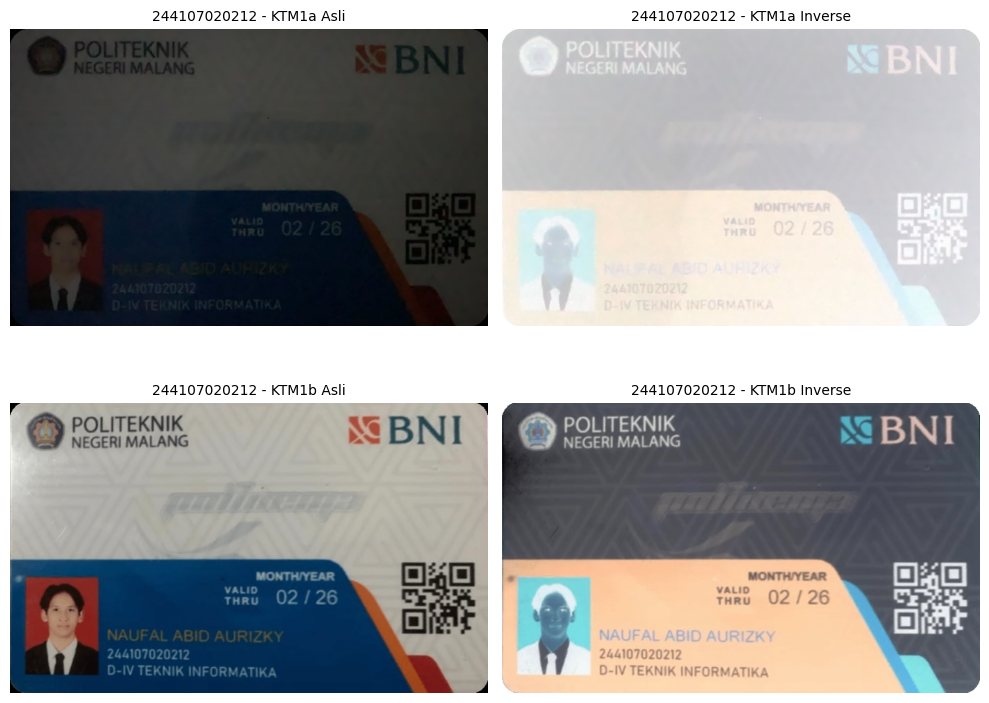

In [11]:
ktm1a = cv.imread(BASE + '/KTM1a.jpg')
ktm1b = cv.imread(BASE + '/KTM1b.jpg')

inv_a = 255 - ktm1a
inv_b = 255 - ktm1b

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
cv2_imshow_rgb(axs[0,0], ktm1a, NIM + ' - KTM1a Asli')
cv2_imshow_rgb(axs[0,1], inv_a, NIM + ' - KTM1a Inverse')
cv2_imshow_rgb(axs[1,0], ktm1b, NIM + ' - KTM1b Asli')
cv2_imshow_rgb(axs[1,1], inv_b, NIM + ' - KTM1b Inverse')
plt.tight_layout()
plt.show()


### Jawaban Analisis Tugas 1

- Histogram KTM1a ktm yang di ruangan gelap nilai pixel rendah, saat di inverse nilai rendah menjadi tinggi (255 - nila_rendah = nilai_tinggi), yang menjadi seluruh citra bergeser ke area terang yang akan menghasilkan terlihat pucat atau berkabut mendekati putih, tidak ada kontras.

- KTM1b dengan pencahayaan ruangan mempunyai histogram lebih merata, sehingga setelah di inverse rentang nilainya tetap lebar yang menghasilkan tetap kontras


## Tugas 2 — Transformasi Kontras

`g(x,y) = a * f(x,y) + b`, dengan `a` = nilai kontras (PARAM['a']) dan `b` = brightness (opsional, bisa 0 atau PARAM['b']).
Karena hasil operasi bisa keluar dari rentang 0–255`


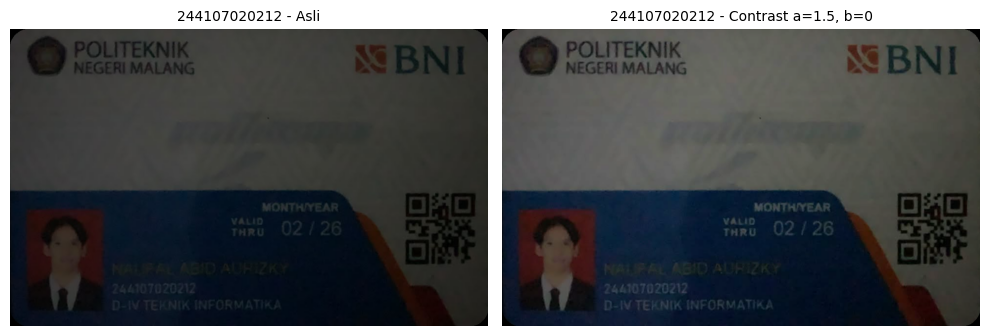

In [12]:
a = PARAM['a']
b = 0

ktm1a = cv.imread(BASE + '/KTM1a.jpg')
contrast_image = np.clip(ktm1a.astype(np.float64) * a + b, 0, 255).astype(np.uint8)

tampil_2(ktm1a, contrast_image,
         NIM + ' - Asli',
         NIM + f' - Contrast a={a}, b={b}')



## Tugas 3 — Transformasi Logarithmic Brightness vs Linear Brightness

- Log brightness: `s = c * log(1 + r)`, dengan `c` = PARAM['c']. Cocok untuk melebarkan detail pada citra gelap tanpa membuat area terang langsung clipping ke 255.
- Linear brightness: `g(x,y) = f(x,y) + b`, dengan `b` = PARAM['b'].


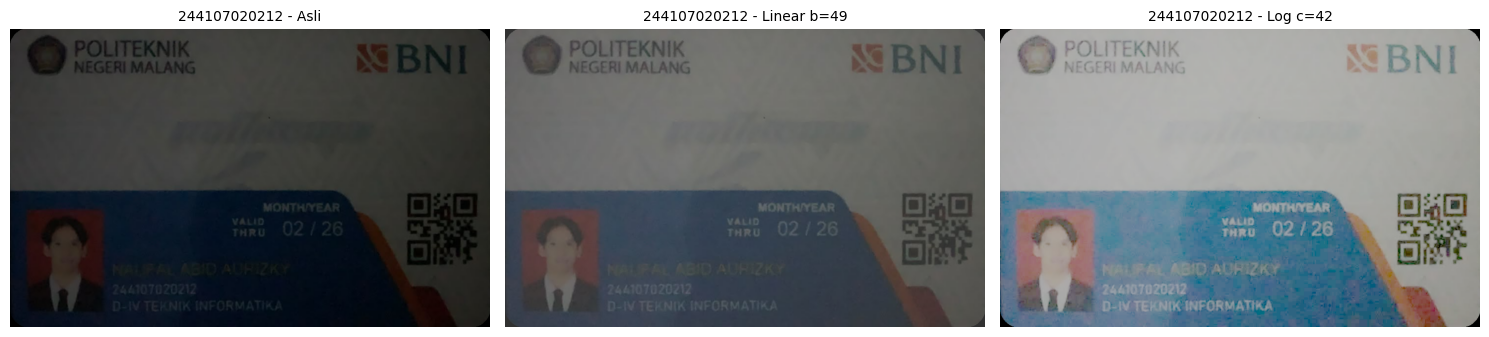

Jumlah pixel clipping (nilai 255) - Linear: 0, Log: 0


In [13]:
c_val = PARAM['c']
b_val = PARAM['b']

ktm1a = cv.imread(BASE + '/KTM1a.jpg')
img_f = ktm1a.astype(np.float64)

# Transformasi Log
log_image = c_val * np.log1p(img_f)          # log1p = log(1+r)
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

# Transformasi Linear
linear_image = np.clip(img_f + b_val, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
cv2_imshow_rgb(axs[0], ktm1a, NIM + ' - Asli')
cv2_imshow_rgb(axs[1], linear_image, NIM + f' - Linear b={b_val}')
cv2_imshow_rgb(axs[2], log_image, NIM + f' - Log c={c_val}')
plt.tight_layout()
plt.show()

clip_linear = np.sum(linear_image == 255)
clip_log = np.sum(log_image == 255)
print(f'Jumlah pixel clipping (nilai 255) - Linear: {clip_linear}, Log: {clip_log}')


## Tugas 4 — Grayscale: Averaging, Lightness, Luminance

- Averaging: `(R+G+B)/3`
- Lightness: `(max(R,G,B) + min(R,G,B)) / 2`
- Luminance: `0.21R + 0.72G + 0.07B` (dipakai pada modul ini)
- Pembanding Luminance: `0.299R + 0.587G + 0.114B` — dipakai di `cv.cvtColor(img, cv.COLOR_BGR2GRAY)`


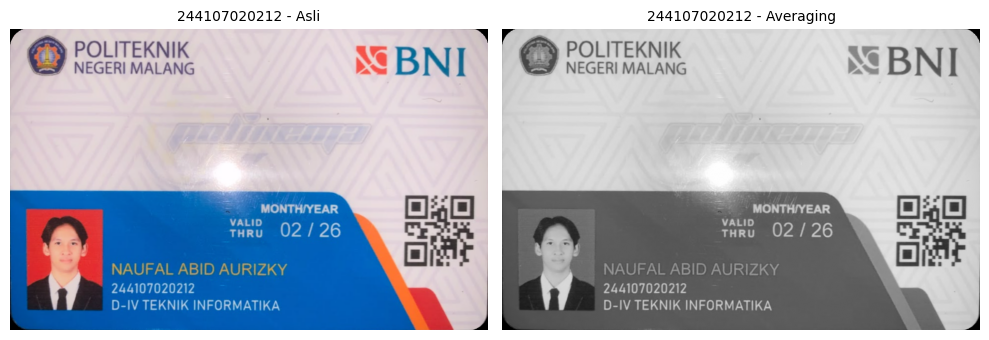

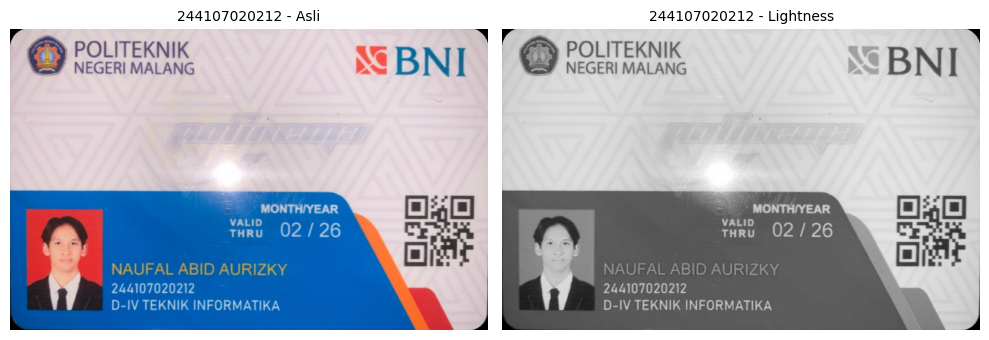

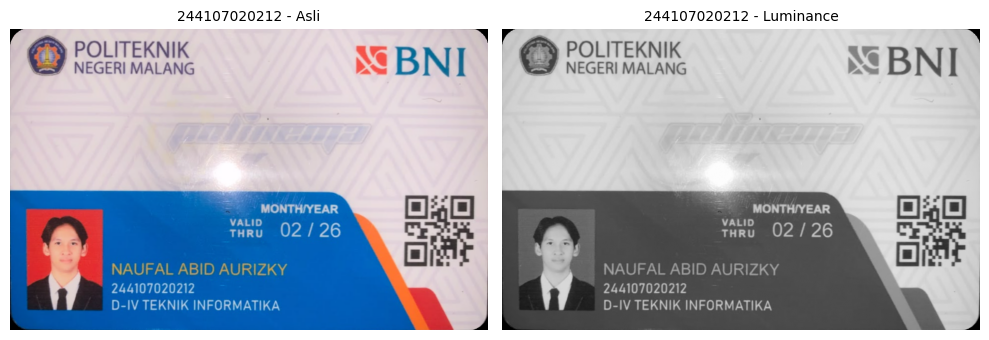

Metode          Mean  simpangan baku
Averaging     165.12         59.01
Lightness     166.38         59.19
Luminance     159.56         64.04


In [21]:
img_c = cv.imread(BASE + '/KTM1c.jpg')
b_ch, g_ch, r_ch = cv.split(img_c.astype(np.float64))

gray_avg    = (r_ch + g_ch + b_ch) / 3
gray_light  = (np.maximum(np.maximum(r_ch, g_ch), b_ch) + np.minimum(np.minimum(r_ch, g_ch), b_ch)) / 2
gray_lum = 0.299 * r_ch + 0.587 * g_ch + 0.114 * b_ch

gray_avg_u8    = np.clip(gray_avg, 0, 255).astype(np.uint8)
gray_light_u8  = np.clip(gray_light, 0, 255).astype(np.uint8)
gray_lum_u8 = np.clip(gray_lum, 0, 255).astype(np.uint8)

# a. Averaging
tampil_2(img_c, gray_avg_u8, NIM + ' - Asli', NIM + ' - Averaging')
# b. Lightness
tampil_2(img_c, gray_light_u8, NIM + ' - Asli', NIM + ' - Lightness')
# c. Luminance
tampil_2(img_c, gray_lum_u8, NIM + ' - Asli', NIM + ' - Luminance')

# Tabel rata-rata dan simpangan baku
print(f"{'Metode':<10}{'Mean':>10}{'simpangan baku':>16}")
for nama, arr in [('Averaging', gray_avg_u8), ('Lightness', gray_light_u8),
                  ('Luminance ', gray_lum_u8)]:
    print(f"{nama:<10}{np.mean(arr):>10.2f}{np.std(arr):>14.2f}")


## Tugas 5 — Color Masking dengan HSV

Mempertahankan satu warna dominan pada citra, dan mengubah bagian lain menjadi grayscale. Menggunakan ruang warna HSV karena lebih mudah menentukan rentang warna dibanding RGB.

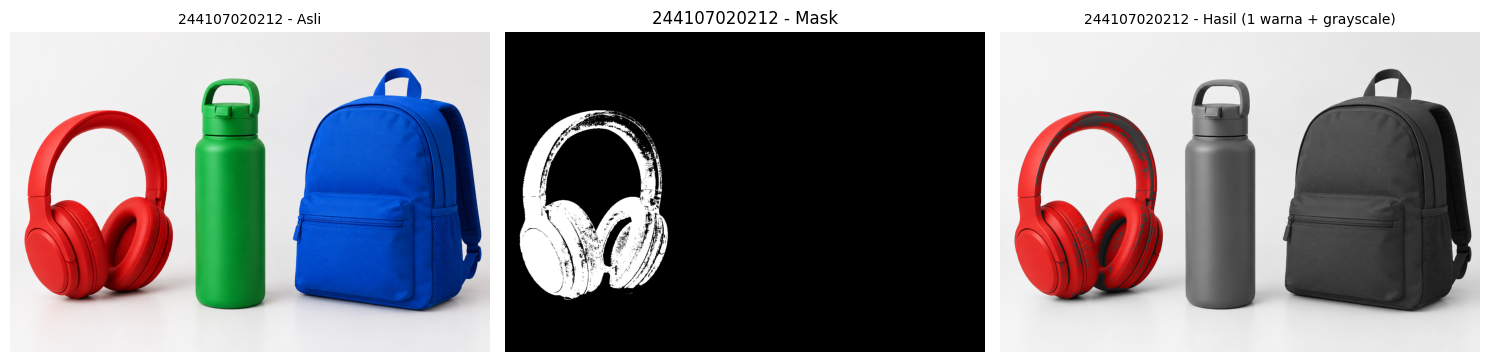

Rentang HSV dipakai -> lower: [  0 100 100]  upper: [ 10 255 255]


In [15]:
img_obj = cv.imread(BASE + '/OBJ1.jpg')
hsv = cv.cvtColor(img_obj, cv.COLOR_BGR2HSV)

lower = np.array([0, 100, 100])
upper = np.array([10, 255, 255])

mask = cv.inRange(hsv, lower, upper)

gray = cv.cvtColor(img_obj, cv.COLOR_BGR2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

result = np.where(mask[:, :, None] == 255, img_obj, gray_3ch)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
cv2_imshow_rgb(axs[0], img_obj, NIM + ' - Asli')
axs[1].imshow(mask, cmap='gray'); axs[1].set_title(NIM + ' - Mask'); axs[1].axis('off')
cv2_imshow_rgb(axs[2], result, NIM + ' - Hasil (1 warna + grayscale)')
plt.tight_layout()
plt.show()

print('Rentang HSV dipakai -> lower:', lower, ' upper:', upper)


## Tugas 6 — Gamma Correction

`I' = 255 * (I/255)^(1/gamma)`. Gamma < 1 mencerahkan citra gelap, gamma > 1 menggelapkan.

Mencoba menginput nilai Gamma secara bertahap sampai menemukan yang membuat NIM dan Nama pada `KTM1a.jpg` paling terbaca.


 Gamma Correction pada citra 
----------------------------------
Nilai gamma hasil hitung NIM Anda: 0.9 (coba mulai dari nilai ini)
Masukkan nilai Gamma percobaan ke-1: 1.8
Masukkan nilai Gamma percobaan ke-2: 1.4
Masukkan nilai Gamma percobaan ke-3: 1.0
Masukkan nilai Gamma percobaan ke-4: 0.6
Masukkan nilai Gamma percobaan ke-5: 0.2


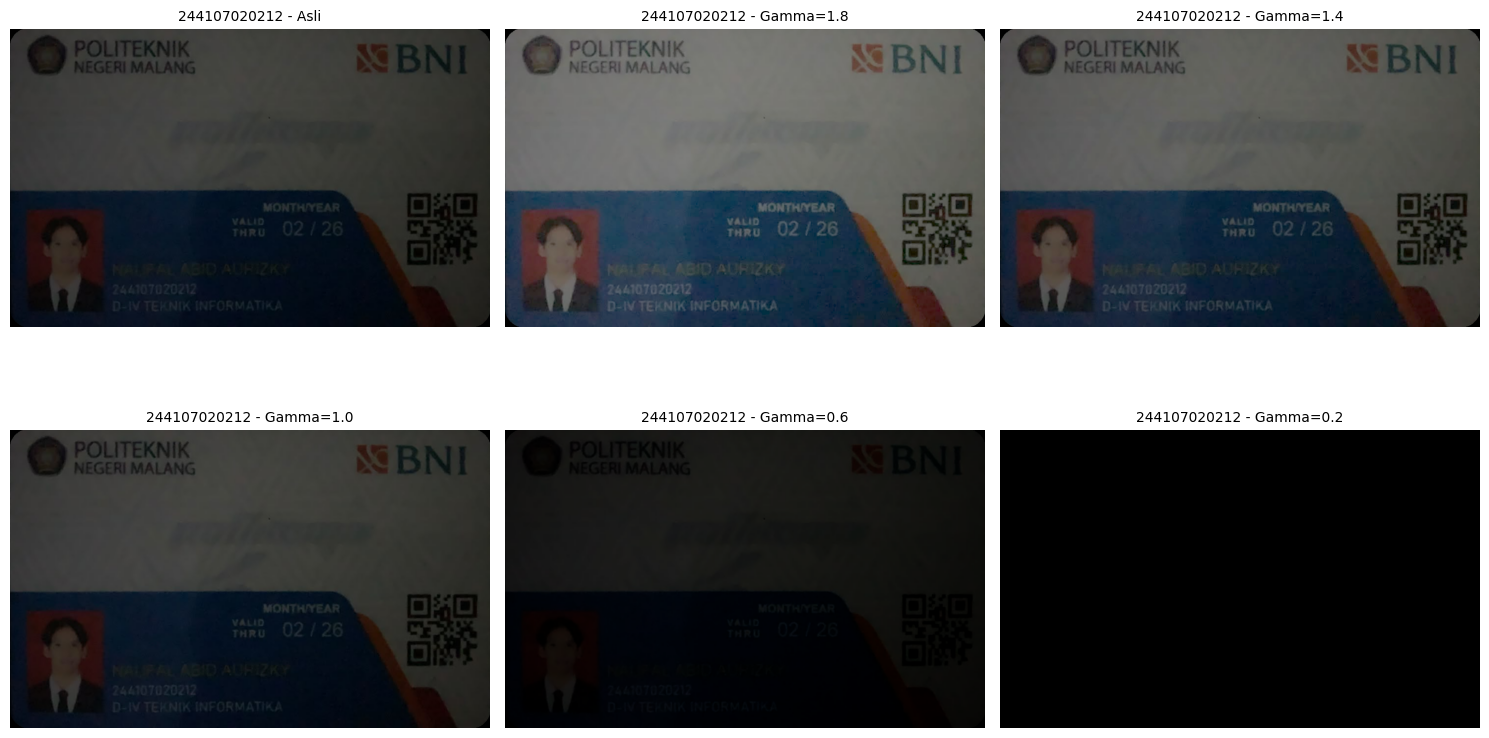

In [24]:
print(' Gamma Correction pada citra ')
print('----------------------------------')

def gamma_correction(img, gamma):
    img_norm = img.astype(np.float64) / 255.0
    corrected = np.power(img_norm, 1.0 / gamma)
    return np.uint8(np.clip(corrected * 255, 0, 255))

ktm1a = cv.imread(BASE + '/KTM1a.jpg')

jumlah_percobaan = 5
gammas_dicoba = []

print(f'Nilai gamma hasil hitung NIM Anda: {PARAM["gamma"]} (coba mulai dari nilai ini)')

for i in range(jumlah_percobaan):
    while True:
        try:
            g = float(input(f'Masukkan nilai Gamma percobaan ke-{i+1}: '))
            if g <= 0:
                print('Nilai gamma harus lebih besar dari 0, coba lagi.')
                continue
            gammas_dicoba.append(g)
            break
        except ValueError:
            print('Error, not a number')

fig, axs = plt.subplots(2, 3, figsize=(15, 9))
cv2_imshow_rgb(axs[0,0], ktm1a, NIM + ' - Asli')
for i, g in enumerate(gammas_dicoba):
    ax = axs.flat[i+1]
    hasil = gamma_correction(ktm1a, g)
    cv2_imshow_rgb(ax, hasil, NIM + f' - Gamma={g}')
plt.tight_layout()
plt.show()

## Tugas 7 — Simulasi Image Depth (Bit Depth)

`level = 255 / (2^bit_depth - 1)`, lalu `C' = round(C/level) * level`. Kode tersebut mensimulasikan pengurangan jumlah warna yang tidak benar benar mengubah ukuran data

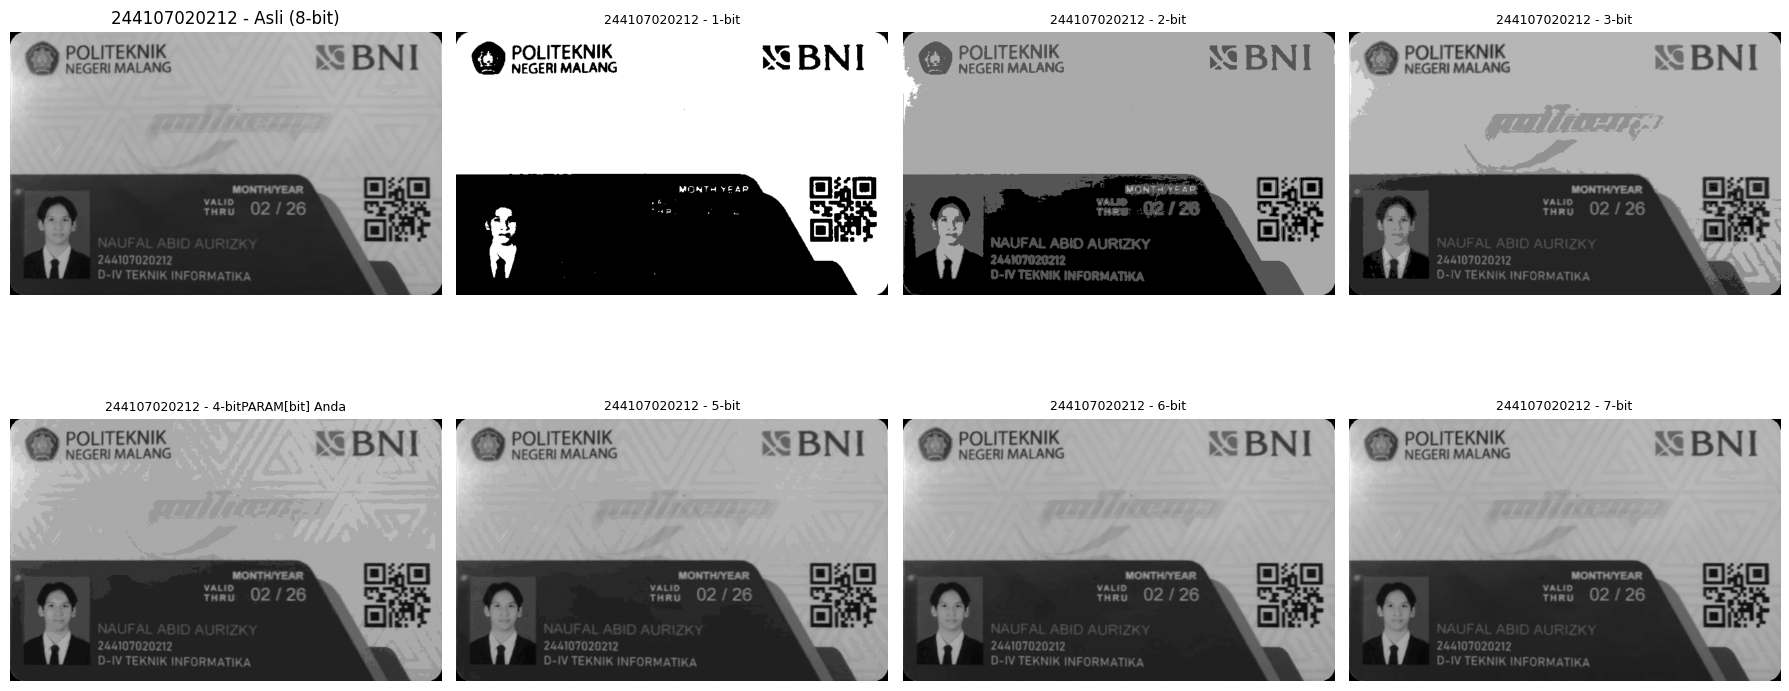

In [26]:
def simulate_bit_depth(img, bit_depth):
    level = 255 / (2 ** bit_depth - 1)
    return np.round(img / level) * level

img_b_gray = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(2, 4, figsize=(18, 9))
axs.flat[0].imshow(img_b_gray, cmap='gray')
axs.flat[0].set_title(NIM + ' - Asli (8-bit)')
axs.flat[0].axis('off')

for i, bit in enumerate(range(1, 8)):
    hasil = simulate_bit_depth(img_b_gray, bit).astype(np.uint8)
    ax = axs.flat[i+1]
    ax.imshow(hasil, cmap='gray')
    tanda = 'PARAM[bit] Anda' if bit == PARAM['bit'] else ''
    ax.set_title(NIM + f' - {bit}-bit{tanda}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## Tugas 8 — Average Denoising & PSNR

Merata-ratakan banyak citra noise lalu akan mengurangi noise acak, sehingga hasil rata-rata makin mendekati citra asli. Kualitas diukur dengan PSNR dan makin tinggi PSNR, makin baik.


In [51]:
# Membaca citra asli
original_galaxy = cv.imread(BASE + '/galaxy.jpg')
if original_galaxy is None:
    raise FileNotFoundError(f'galaxy.jpg tidak ditemukan di: {BASE}')

# Membaca seluruh citra noise dalam folder
cv_img = []
for img in glob.glob(BASE + '/noises/*.jpg'):
    n = cv.imread(img)
    if n is not None:
        cv_img.append(n)

print('Jumlah citra noise terbaca:', len(cv_img))

# STOP di sini kalau masih 0 -- jangan lanjut ke sel berikutnya sebelum ini > 0
assert len(cv_img) > 0, "cv_img masih kosong! Cek lagi path BASE dan folder noises."

Jumlah citra noise terbaca: 100


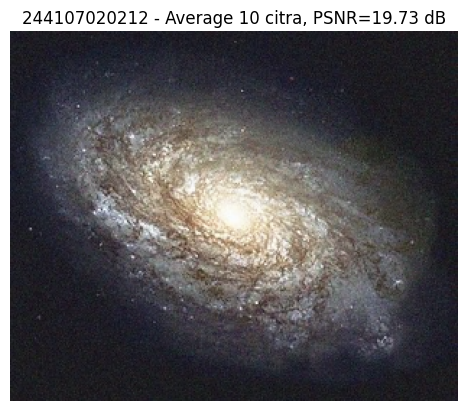

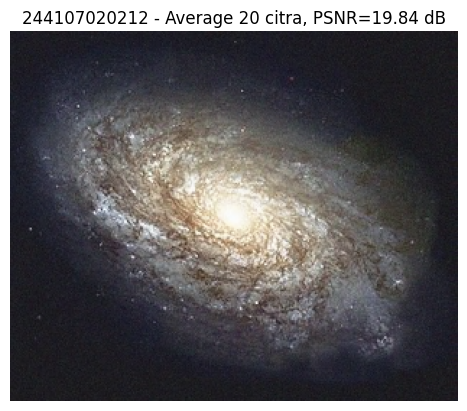

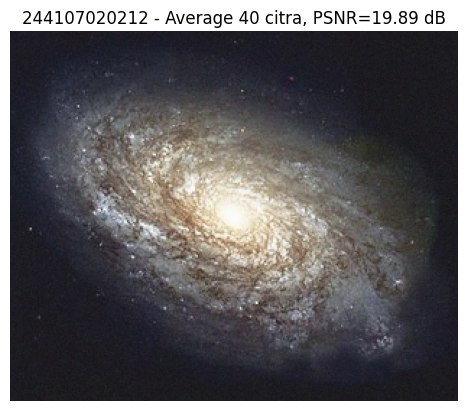

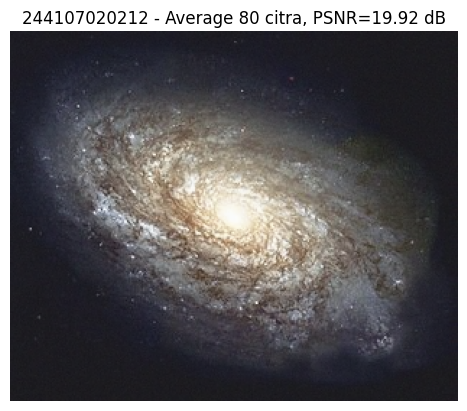

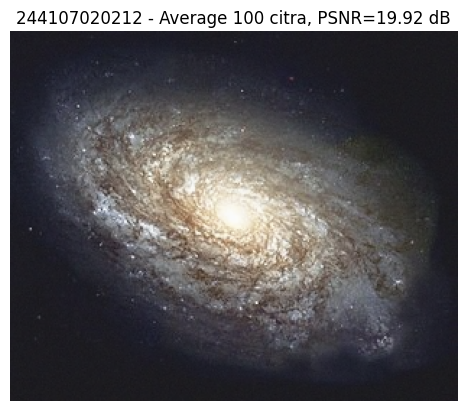

Jumlah Citra      PSNR (dB)
10                    19.73
20                    19.84
40                    19.89
80                    19.92
100                   19.92


In [55]:
def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

jumlah_list = [10, 20, 40, 80, 100]
jumlah_list = [n for n in jumlah_list if n <= len(cv_img)]

hasil_psnr = {}
hasil_gambar = {}

for n in jumlah_list:
    avg_img = np.mean(cv_img[:n], axis=0).astype(np.uint8)
    psnr_val = PSNR(original_galaxy, avg_img)
    hasil_psnr[n] = psnr_val
    hasil_gambar[n] = avg_img

    plt.figure()
    plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
    plt.title(NIM + f' - Average {n} citra, PSNR={psnr_val:.2f} dB')
    plt.axis('off')
    plt.show()

print(f"{'Jumlah Citra':<15}{'PSNR (dB)':>12}")
for n in jumlah_list:
    print(f"{n:<15}{hasil_psnr[n]:>12.2f}")

Ukuran citra (h, w): 555 879


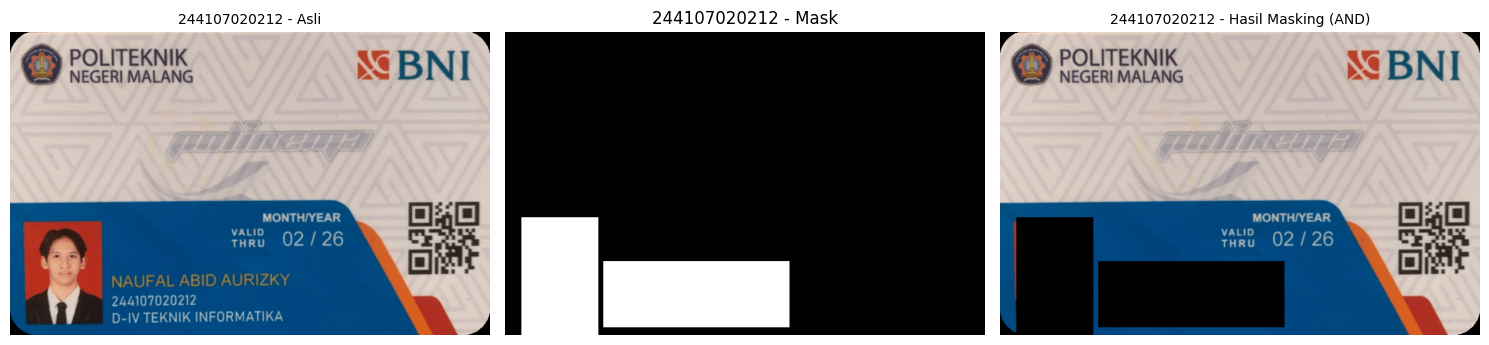

Koordinat mask wajah: (50,50)-(200,200)  <- GANTI
Koordinat mask NIM  : (300,400)-(500,450) <- GANTI


In [129]:
img_d = cv.imread(BASE + '/KTM1d.jpg')
h, w = img_d.shape[:2]
print('Ukuran citra (h, w):', h, w)

mask = np.zeros((h, w), dtype=np.uint8)


cv.rectangle(mask, (30, 650), (170, 340), 255, -1)    # area foto wajah
cv.rectangle(mask, (180, 540), (520, 420), 255, -1)  # area NIM

mask_inv = cv.bitwise_not(mask)
mask_inv_3ch = cv.cvtColor(mask_inv, cv.COLOR_GRAY2BGR)
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

masked_result = cv.bitwise_and(img_d, mask_inv_3ch)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
cv2_imshow_rgb(axs[0], img_d, NIM + ' - Asli')
axs[1].imshow(mask, cmap='gray'); axs[1].set_title(NIM + ' - Mask'); axs[1].axis('off')
cv2_imshow_rgb(axs[2], masked_result, NIM + ' - Hasil Masking (AND)')
plt.tight_layout()
plt.show()

print('Koordinat mask wajah: (50,50)-(200,200)  <- GANTI')
print('Koordinat mask NIM  : (300,400)-(500,450) <- GANTI')


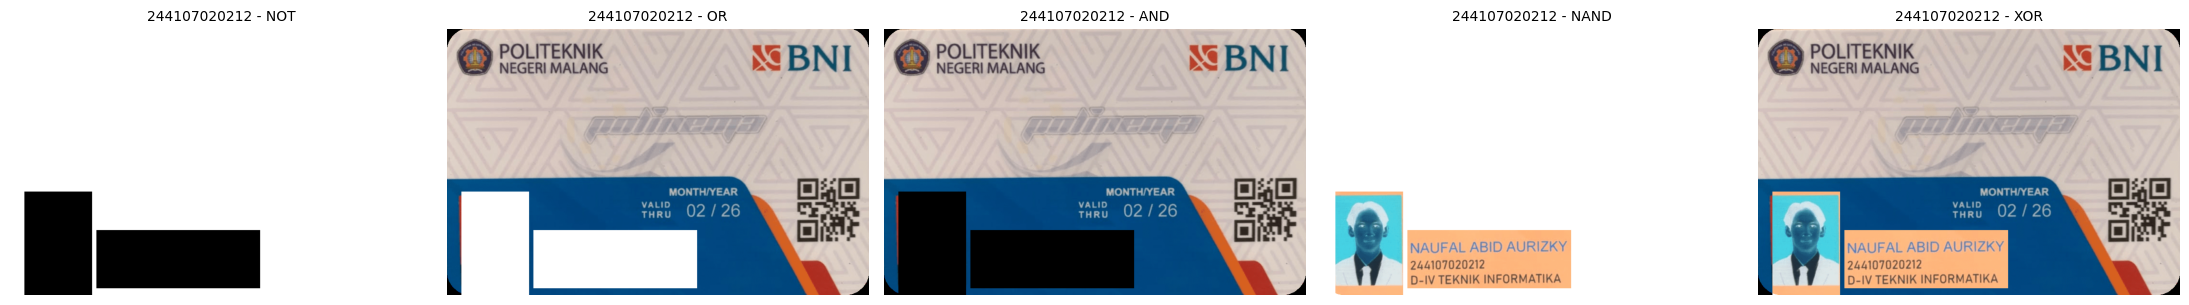

In [130]:
# Eksperimen operator logika lain pada mask yang sama
img_not  = cv.bitwise_not(mask_3ch)
img_or   = cv.bitwise_or(img_d, mask_3ch)
img_and  = cv.bitwise_and(img_d, mask_inv_3ch)
img_nand = cv.bitwise_not(cv.bitwise_and(img_d, mask_3ch))
img_xor  = cv.bitwise_xor(img_d, mask_3ch)

fig, axs = plt.subplots(1, 5, figsize=(22, 5))
cv2_imshow_rgb(axs[0], img_not,  NIM + ' - NOT')
cv2_imshow_rgb(axs[1], img_or,   NIM + ' - OR')
cv2_imshow_rgb(axs[2], img_and,  NIM + ' - AND')
cv2_imshow_rgb(axs[3], img_nand, NIM + ' - NAND')
cv2_imshow_rgb(axs[4], img_xor,  NIM + ' - XOR')
plt.tight_layout()
plt.show()


## Tugas 10 — Perbaikan Kualitas Foto Malam Hari

Foto malam hari yang gelap biasanya punya detail tersembunyi di area gelap (histogram menumpuk di nilai rendah).

Penjelasan :
Jelaskan:
- Metode yang dipilih :
(mis. Gamma Correction, karena mampu mencerahkan area gelap tanpa langsung membuat area terang clipping seperti linear brightness).
- Alasan pemilihan:
dikaitkan dengan sifat citra malam hari (histogram menumpuk di nilai rendah).
- Parameter terbaik:
coba beberapa nilai gamma/a/b/c, tentukan mana yang paling menampilkan detail tanpa membuat noise berlebihan atau area terang jadi over-exposed.
- Before-after:
sudah ditampilkan di atas — jelaskan detail apa yang mulai terlihat setelah diproses.
- Risiko metode:
misalnya, menaikkan gamma/brightness terlalu tinggi bisa memunculkan noise pada area yang sangat gelap, atau membuat area yang sudah terang jadi clipping.

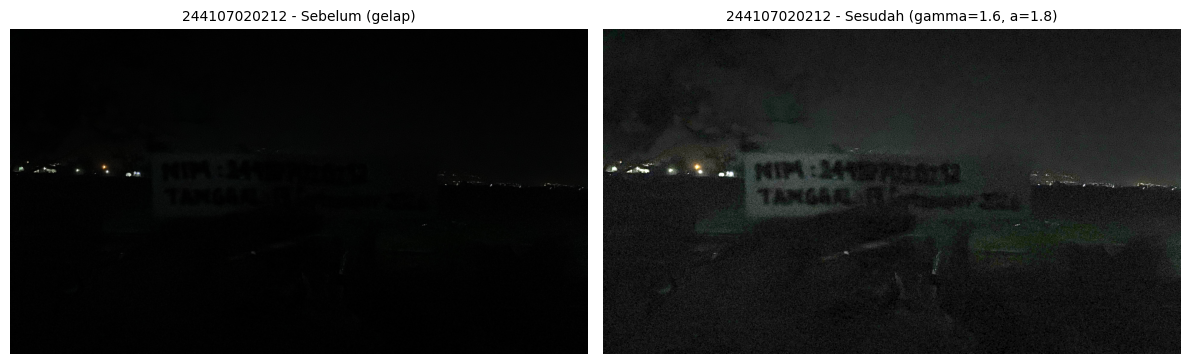

In [134]:
img_night = cv.imread(BASE + '/NIGHT1.jpg')

# Contoh kombinasi: Gamma Correction (mencerahkan) + sedikit Contrast
gamma_pilihan = 1.6         # < 1 karena foto gelap, cari nilai terbaik lewat percobaan
a_pilihan = 1.8               # sedikit menambah kontras agar detail lebih tegas

img_norm = img_night.astype(np.float64) / 255.0
step1 = np.power(img_norm, 1.0 / gamma_pilihan) * 255.0
step2 = np.clip(step1 * a_pilihan, 0, 255).astype(np.uint8)

tampil_2(img_night, step2,
         NIM + ' - Sebelum (gelap)',
         NIM + f' - Sesudah (gamma={gamma_pilihan}, a={a_pilihan})',
         figsize=(12,6))
